# Attention prior for DeltaNMF

Design doc: [`idea.md`](../idea.md).

## What is new vs what is reused

| Piece | Source | Role |
|---|---|---|
| **Embedding-NMF** | [DeltaNMF](../third_party/deltanmf) | Baseline: scGPT embeddings → `S_E` → graph-regularized NMF |
| **`S_E` construction** | [DeltaNMF scGPT script](../third_party/deltanmf/resources/scgpt/create_transformer_similarity_matrix_scgpt.py) | `model.encoder` → corrcoef → ReLU |
| **NMF solver** | `deltanmf.models.solve_ntc_regularized` | Same neural NMF for every arm |
| **Attention → `S_att`** | scGPT paper's attention-map recipe on a [paper-exact replica](../src/attn_enhance/scgpt_attention.py) of its pretraining layers | **Novel prior** |
| **Attention-NMF / Combined** | this project | Same DeltaNMF solver; swap / mix `S_E` ← `S_att` |

## Mental model

```
X (cells × genes)
        │
        ├─► frozen scGPT embeddings ──► S_E      ──┐
        │                                          ├─► DeltaNMF solver ──► W, H
        └─► frozen scGPT attention  ──► S_att ────┘
```

**Question:** does contextual `S_att` change recovered programs relative to DeltaNMF’s static `S_E`?

This notebook walks the pipeline with **intermediate visuals** so you can see the data at each stage — not only the final bar chart.

> On synthetic $X$ this is **pipeline visualization**. Biological claims need real data + markers/pathways ([idea.md](../idea.md) §17-D).

## 0. Setup

Kernel: **Python (attention)**. We put `src/` and vendored DeltaNMF on `sys.path`, then import helpers.

What each import is for:
- `genes_from_scgpt_vocab` / `make_synthetic_expression` — build a toy $X$ scGPT can tokenize
- `extract_scgpt_priors` — frozen checkpoint → `S_E` and `S_att`
- `load_pretrained_scgpt` — the paper-exact scGPT transformer replica (used to verify the layer in §2)
- `run_program_discovery_experiment` — four-arm DeltaNMF matrix + $\alpha$ sweep
- `plot_*` — intermediate and comparison figures

In [1]:
from __future__ import annotations

import copy
import math
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import torch
from einops import rearrange
from scipy.cluster.hierarchy import leaves_list, linkage
from scipy.spatial.distance import squareform

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "third_party" / "deltanmf"))

from attn_enhance import (
    genes_from_scgpt_vocab,
    make_synthetic_expression,
    extract_scgpt_priors,
    load_pretrained_scgpt,
    paper_attention_map,
    bin_expression,
    rank_normalize_attention,
    fit_deltanmf,
    graph_laplacian,
    graph_smoothness,
    run_program_discovery_experiment,
    format_comparison,
    DEFAULT_ALPHAS,
    top_edges,
    plot_synthetic_atlas,
    plot_prior_edge_diagnostics,
    plot_prior_comparison,
    plot_recon_comparison,
    plot_program_loadings,
    plot_top_genes_comparison,
    plot_cell_program_usage,
    plot_arm_W_similarity,
)

SCGPT_DIR = ROOT / "checkpoints" / "scgpt"
for f in ("best_model.pt", "vocab.json", "args.json"):
    if not (SCGPT_DIR / f).exists():
        raise FileNotFoundError(f"Missing {SCGPT_DIR / f}")

print("project:", ROOT)
print("device:", "cuda" if torch.cuda.is_available() else "cpu")
print("checkpoint:", SCGPT_DIR)

project: /Users/albert/Documents/attention
device: cpu
checkpoint: /Users/albert/Documents/attention/checkpoints/scgpt


## 1. Expression matrix $X$

DeltaNMF / NMF factorize

$$
X \approx WH,
\qquad W\in\mathbb{R}_+^{G\times K}\ (\text{gene–program loadings}),
\quad H\in\mathbb{R}_+^{K\times N}\ (\text{program activity per cell}).
$$

Until a real cohort is plugged in ([idea.md](../idea.md) §15), we use a **small synthetic** atlas:

1. Gene symbols come from the scGPT vocab (placeholders like `G000` cannot be tokenized by a real checkpoint).
2. We **plant** $K$ gene programs (`program_W`, `program_H`) and form $X \approx W H$ + noise.
3. The figures below show what the model will see (`X`) and the ground-truth factors (for sanity only — not available on real data).

> Later: replace with AnnData —  
> `X = np.asarray(adata.X.todense() if hasattr(adata.X, "todense") else adata.X)`  
> `names = list(adata.var_names)`.

X shape (cells × genes): (80, 48)
genes: ['CD3D', 'CD3E', 'CD8A', 'CD4', 'MS4A1', 'CD79A', 'NKG7', 'GNLY', 'LYZ', 'S100A8'] ...
planted W: (48, 4) | planted H: (80, 4)
X range: [0.000, 2.369]  mean=0.393
  planted program 0: 10 genes → ['CD3D', 'CD3E', 'CD8A', 'CD4', 'MS4A1'] ...
  planted program 1: 12 genes → ['LYZ', 'S100A8', 'S100A9', 'CST3', 'FCGR3A'] ...
  planted program 2: 12 genes → ['IL7R', 'CCR7', 'GZMB', 'PRF1', 'CCL5'] ...
  planted program 3: 12 genes → ['STAT1', 'IRF7', 'ACTB', 'GAPDH', 'B2M'] ...


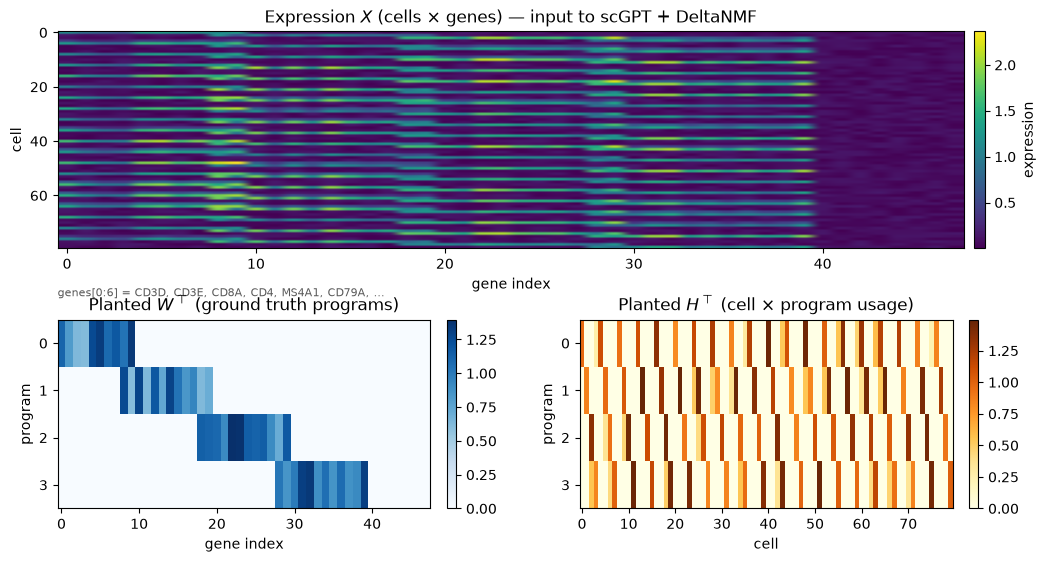

In [2]:
N_GENES, N_CELLS, K = 48, 80, 4
names = genes_from_scgpt_vocab(SCGPT_DIR, n_genes=N_GENES, seed=0)
atlas = make_synthetic_expression(
    n_cells=N_CELLS, n_genes=N_GENES, n_programs=K, gene_names=names, seed=0
)
X = atlas.X

print("X shape (cells × genes):", X.shape)
print("genes:", names[:10], "...")
print("planted W:", atlas.program_W.shape, "| planted H:", atlas.program_H.shape)
print("X range: [{:.3f}, {:.3f}]  mean={:.3f}".format(X.min(), X.max(), X.mean()))
for k, idxs in enumerate(atlas.program_gene_sets):
    print(f"  planted program {k}: {len(idxs)} genes →", [names[i] for i in idxs[:5]], "...")

plot_synthetic_atlas(X, atlas.program_W, atlas.program_H, gene_names=names)
plt.show()

### What to look for in the atlas figure

| Panel | What it shows | Why it matters |
|---|---|---|
| **$X$** | Observed expression | This is the only matrix DeltaNMF reconstructs |
| **Planted $W^\top$** | Blocky gene membership | Ground truth for later “did we recover programs?” checks |
| **Planted $H^\top$** | Which cells use which program | Explains the striped / blocky look in $X$ |

Gene *symbols* look biological (immune markers) because we sampled real vocab names; the *expression pattern* is still synthetic.

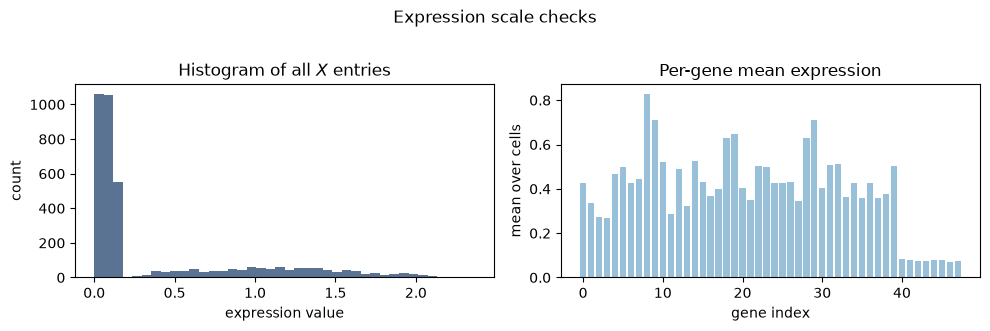

In [3]:
# Extra intermediate view: expression distribution + per-gene means.
# Helps confirm X is non-negative and not pathological before loading scGPT.
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))

axes[0].hist(X.ravel(), bins=40, color="#3d5a80", alpha=0.85)
axes[0].set_xlabel("expression value")
axes[0].set_ylabel("count")
axes[0].set_title(r"Histogram of all $X$ entries")

gene_mean = X.mean(axis=0)
axes[1].bar(np.arange(len(gene_mean)), gene_mean, color="#98c1d9")
axes[1].set_xlabel("gene index")
axes[1].set_ylabel("mean over cells")
axes[1].set_title("Per-gene mean expression")

fig.suptitle("Expression scale checks", y=1.02)
fig.tight_layout()
plt.show()

## 2. Build the two gene–gene priors

Both priors are $G\times G$ similarity graphs over the **same** gene set. Only the *source* of edges differs.

### $S_E$ — DeltaNMF default (static)

$$
e_i = \texttt{model.encoder}(\text{gene}_i),
\qquad
S_E{ij} = \max\bigl(0,\operatorname{corr}(e_i,e_j)\bigr).
$$

Interpretation: genes with similar **pretrained embeddings** are linked. No dependence on this dataset’s expression beyond which genes are present.

### $S^{att}$ — novel (contextual), from the paper's exact attention layer

The transformer is a pure-PyTorch replica of the flash-attn layers scGPT was pretrained with ([`scgpt_attention.py`](../src/attn_enhance/scgpt_attention.py)). It has the paper's architecture: 512-d embeddings, 12 blocks × 8 heads, feed-forward hidden size 512, post-LayerNorm, and ReLU. Its parameter names match the checkpoint, so the weights load strictly. Each block computes paper Eq. 10:

$$
\operatorname{Attention}(Q,K,V)=\operatorname{softmax}\!\Bigl(\frac{QK^\top}{\sqrt d}+A_{\text{mask}}\Bigr)V,
\qquad Q=hW_q,\ K=hW_k,\ V=hW_v,\ d=64.
$$

Every gene in our cells is observed ("known"), so the generative-pretraining mask $A_{\text{mask}}$ (Eq. 11) is all zeros here, which means full self-attention.

> **Why a replica?** Without flash-attn (e.g. on a Mac), scGPT falls back to `nn.TransformerEncoderLayer`, which names its Q/K/V projection `in_proj_weight`. The checkpoint's `Wqkv` is then skipped without any error, leaving random attention weights in all 12 blocks. The replica refuses to load if any weight is missing.

Attention-map recipe (paper Methods, "attention-based target gene selection"):

1. Bin each cell's expression into per-cell quantile bins (Eq. 2, 51 bins). Prepend `<cls>` with value −2, as in pretraining.
2. Run blocks $0..L-1$. At block $L$, take the raw $QK^\top$ for all 8 heads.
3. Rank-normalize by row, then by column, then average the heads to get $A^{(c)}$.
4. Average over cells and drop `<cls>`. Then, as this project's addition rather than the paper's, symmetrize and $k$NN-sparsify:

$$
\bar A_{ij}=\tfrac1{N_D}\sum_{c\in D}A^{(c)}_{ij},
\qquad
S^{att}_{ij}=\tfrac12(\bar A_{ij}+\bar A_{ji}).
$$

Interpretation: genes the model **attends between in this cellular context**. Association, not proven regulation ([idea.md](../idea.md) §10).

`layer_index=None` selects the last transformer layer, as in the paper. Treat it as an ablation variable.

In [4]:
priors = extract_scgpt_priors(
    X, names, SCGPT_DIR,
    layer_index=None,   # last layer; try 3, 6, 9, … as an ablation
    max_cells=24,       # subset of cells used to aggregate attention
    batch_size=4,
    dry_run=False,
    attention_knn=8,    # sparsify S_att so hubs do not dominate unchecked
)

S_E = priors.embedding.similarity
S_att = priors.attention.similarity

print("extraction recipes")
print("  S_E  :", priors.embedding.meta.get("extraction"))
print("  S_att:", priors.attention.meta.get("extraction"))
print("weights:", priors.meta.get("weights"))
print("shapes:", S_E.shape, S_att.shape, "| layer", priors.meta.get("layer_index"))
print("genes kept:", len(priors.gene_names))
print("density (frac > 0):  S_E={:.3f}  S_att={:.3f}".format(
    np.mean(S_E > 0), np.mean(S_att > 0)
))
print("top S_E edges:", top_edges(S_E, priors.gene_names, k=5))
print("top S_att edges:", top_edges(S_att, priors.gene_names, k=5))

extraction recipes
  S_E  : DeltaNMF create_transformer_similarity_matrix_scgpt.py
  S_att: scGPT paper recipe: binned input + <cls> -> replica flash layers -> raw QK^T (all heads) -> rank-norm row, col -> mean heads -> mean cells
weights: loaded 154 tensors (strict); skipped decoder heads ['decoder', 'mvc_decoder']; config deviations from paper: none
shapes: (48, 48) (48, 48) | layer 11
genes kept: 48
density (frac > 0):  S_E=0.855  S_att=0.211
top S_E edges: [('C1QA', 'C1QB', 0.8744554689487443), ('S100A8', 'S100A9', 0.8594098138486407), ('MT-CO1', 'MT-CO2', 0.7818272229045773), ('HLA-A', 'HLA-B', 0.7608337562234971), ('PPBP', 'PF4', 0.6892156040690979)]
top S_att edges: [('MT-CO1', 'MT-CO2', 0.6378082583347957), ('MALAT1', 'MT-CO2', 0.6279761989911397), ('MALAT1', 'MT-CO1', 0.6198448290427526), ('ACTB', 'MT-CO1', 0.5959290067354839), ('CXCL10', 'STAT1', 0.5932716925938923)]


### Is this really the paper's layer?

Three checks before trusting $S^{att}$:

1. **Architecture**: the config matches the paper (512 / 12 blocks / 8 heads / 512), and the last block prints as `Wqkv → attention → out_proj`, then a ReLU feed-forward network with post-LayerNorm.
2. **Weights**: every block's `Wqkv` is bit-identical to the checkpoint, so no random attention remains.
3. **Intermediate output**: the directed, rank-normalized map $\bar A$ (paper recipe, before our symmetrize + $k$NN) next to the final $S^{att}$.

`tests/test_scgpt_attention.py` also checks the replica numerically against PyTorch's own encoder layer, the upstream masked cross-attention, and the official tutorial's rank normalization (`pytest tests`).

loaded 154 tensors (strict); skipped decoder heads ['decoder', 'mvc_decoder']; config deviations from paper: none
config: {'embsize': 512, 'nlayers': 12, 'nheads': 8, 'd_hid': 512}
ScGPTLayer(
  (self_attn): ScGPTMultiheadAttention(
    (Wqkv): Linear(in_features=512, out_features=1536, bias=True)
    (out_proj): Linear(in_features=512, out_features=512, bias=True)
  )
  (linear1): Linear(in_features=512, out_features=512, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (linear2): Linear(in_features=512, out_features=512, bias=True)
  (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
  (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (dropout2): Dropout(p=0.2, inplace=False)
)
all 12 pretrained Wqkv loaded: True


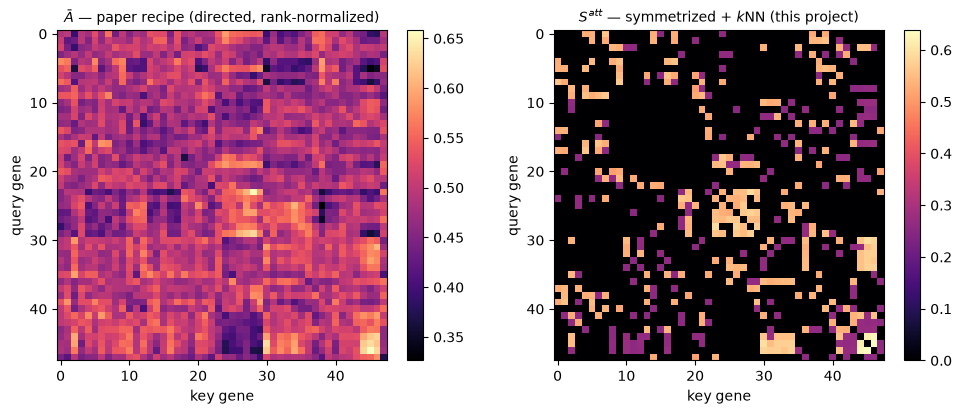

In [5]:
replica, _vocab, cfg, report = load_pretrained_scgpt(SCGPT_DIR, device="cpu")
print(report.summary())
print("config:", {k: cfg[k] for k in ("embsize", "nlayers", "nheads", "d_hid")})
print(replica.transformer_encoder.layers[-1])

ckpt = torch.load(SCGPT_DIR / "best_model.pt", map_location="cpu", weights_only=True)
wqkv_loaded = all(
    torch.equal(layer.self_attn.Wqkv.weight, ckpt[f"transformer_encoder.layers.{i}.self_attn.Wqkv.weight"])
    for i, layer in enumerate(replica.transformer_encoder.layers)
)
print("all 12 pretrained Wqkv loaded:", wqkv_loaded)
del ckpt, replica

A_bar = priors.attention.meta["raw_attention"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, M, title in [
    (axes[0], A_bar, r"$\bar A$ — paper recipe (directed, rank-normalized)"),
    (axes[1], S_att, r"$S^{att}$ — symmetrized + $k$NN (this project)"),
]:
    im = ax.imshow(M, cmap="magma")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("key gene")
    ax.set_ylabel("query gene")
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
plt.show()

### Intermediate prior diagnostics

Before the side-by-side heatmaps, inspect **edge-weight scale** and **per-gene degree**.

- If $S_E$ has many mid/high correlations and $S^{att}$ is sparse with a few hubs, they are already different objects.
- Top $S_E$ edges often look like known co-families (e.g. `S100A8–S100A9`); top $S^{att}$ edges after $k$NN often look hub-like. That contrast is expected, not a bug.

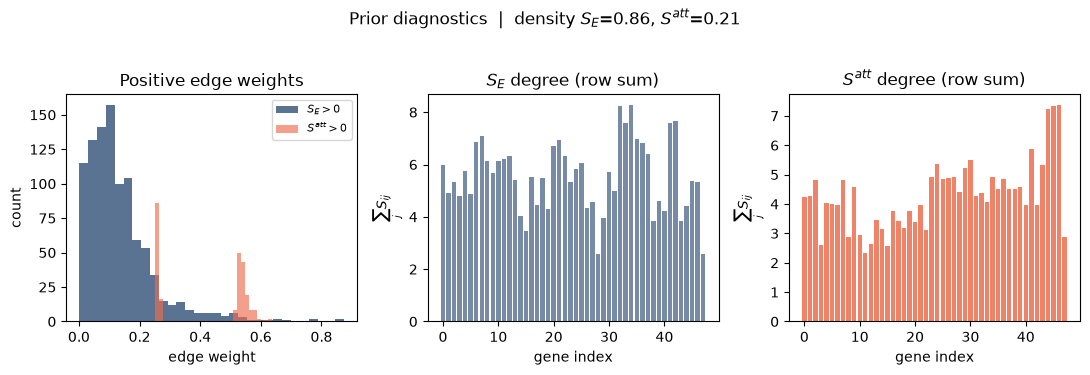

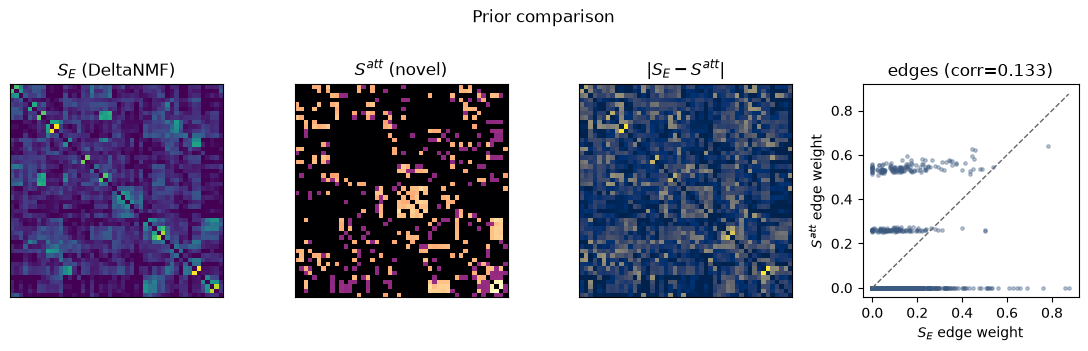

In [6]:
plot_prior_edge_diagnostics(priors)
plt.show()

plot_prior_comparison(priors)
plt.show()

### How to read the prior figures

| Panel | Question it answers |
|---|---|
| Weight histograms / degrees | Are the graphs on comparable scales? Is attention hubby? |
| $S_E$ heatmap | Dense static similarity (DeltaNMF default) |
| $S^{att}$ heatmap | Sparse contextual graph (novel) |
| $|S_E - S^{att}|$ | Where they disagree |
| Edge scatter + corr | Are strong $S_E$ edges also strong in attention? (often **no**) |

A near-zero / negative upper-triangle correlation is evidence that attention is **not** a duplicate of embeddings ([idea.md](../idea.md) §17-B).

### 2b. The gene × gene attention graph, up close

Three $G\times G$ matrices over the same genes, reordered by hierarchical clustering of $S^{att}$ so communities sit in diagonal blocks:

| Matrix | What it is |
|---|---|
| $\bar A$ | Raw cell-averaged attention (paper recipe). **Directed**: row = query gene, column = key gene. Dense: every gene attends to every gene. |
| $S^{att}$ | $\tfrac12(\bar A + \bar A^\top)$, then keep each gene's 8 strongest neighbours. **This is the graph.** |
| $L = D - S^{att}$ | The graph Laplacian DeltaNMF builds internally (`third_party/deltanmf/deltanmf/models.py`: `L_S_tensor = D_E - S_E`). Diagonal = weighted degree, off-diagonal = $-S^{att}_{ij}$. This is the only form in which the graph touches NMF. |

The network drawing shows the same $S^{att}$: node = gene, edge width ∝ weight, node size ∝ weighted degree, colour = planted synthetic program (grey = noise-only gene). The planted programs are random gene blocks, so there is no reason for scGPT's biology-driven graph to follow the colours.

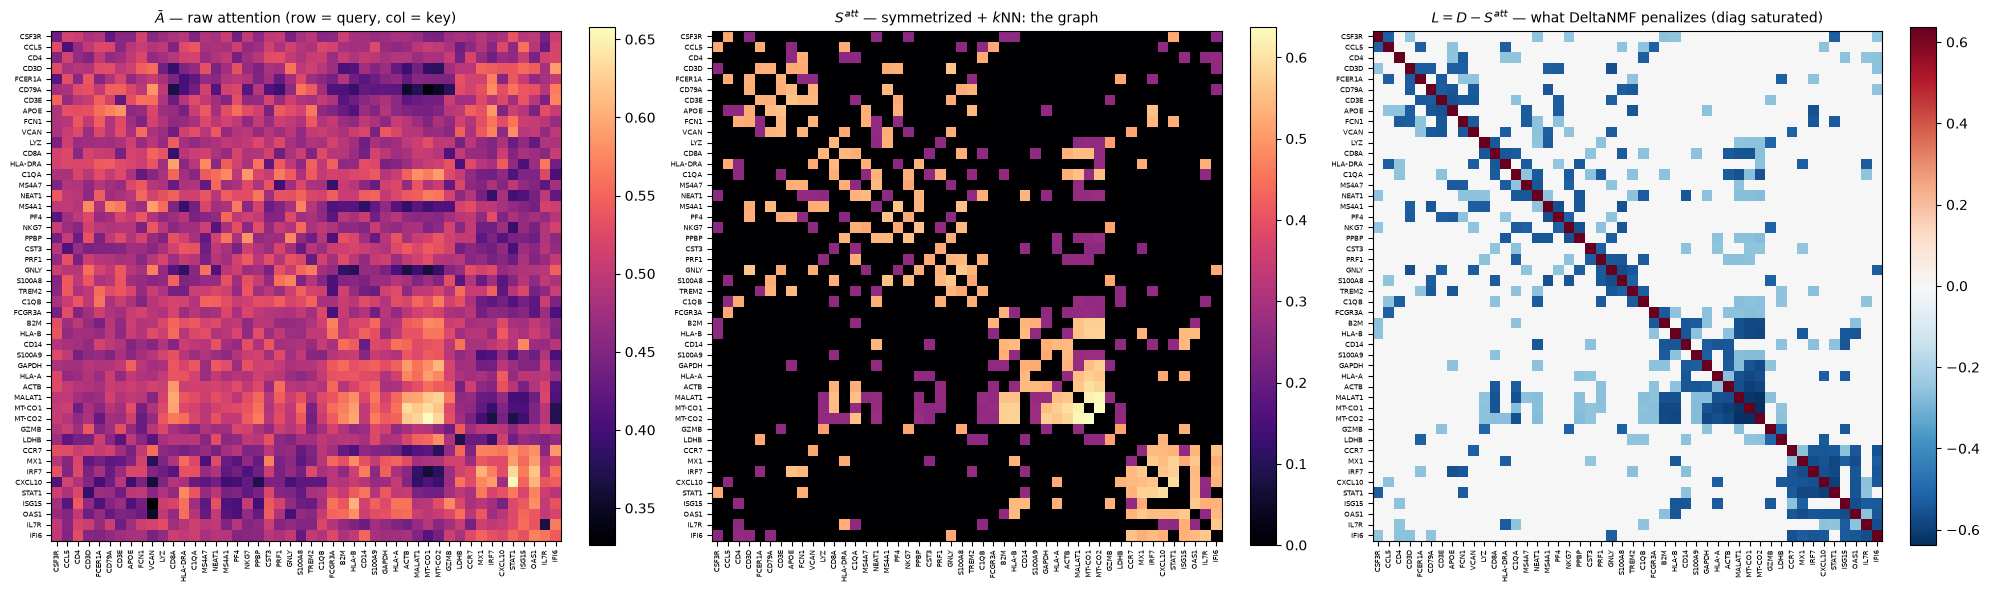

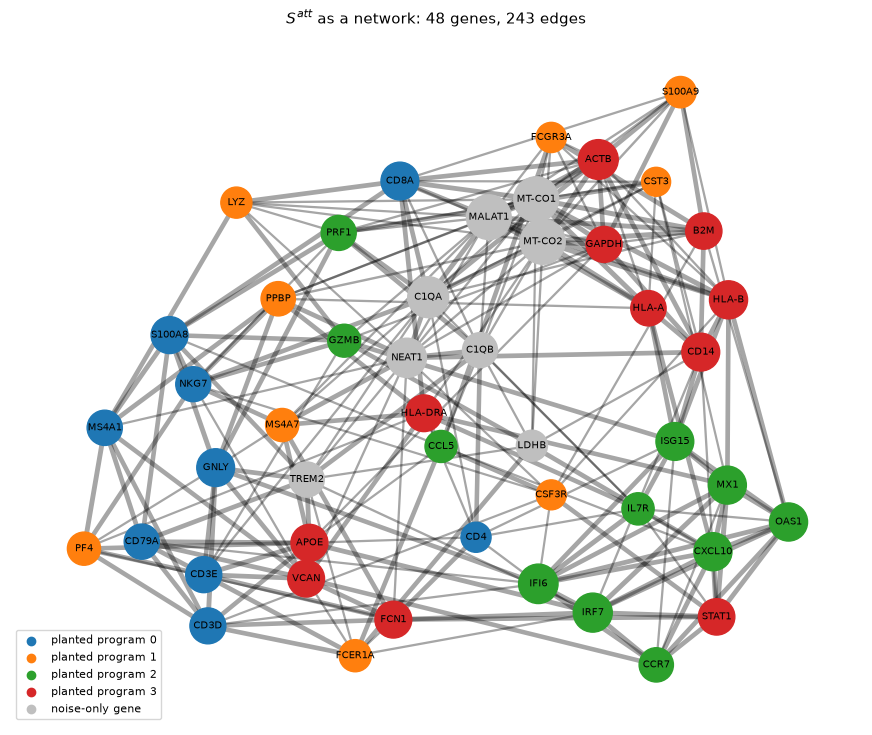

top 10 edges:
  ('MT-CO1', 'MT-CO2', 0.6378082583347957)
  ('MALAT1', 'MT-CO2', 0.6279761989911397)
  ('MALAT1', 'MT-CO1', 0.6198448290427526)
  ('ACTB', 'MT-CO1', 0.5959290067354839)
  ('CXCL10', 'STAT1', 0.5932716925938923)
  ('ACTB', 'MT-CO2', 0.5825361361106236)
  ('HLA-B', 'MT-CO2', 0.5795599619547527)
  ('MX1', 'STAT1', 0.5786564648151398)
  ('HLA-B', 'MT-CO1', 0.5774872402350107)
  ('HLA-A', 'MT-CO1', 0.5754145582516987)
top 5 hubs (weighted degree): [('MT-CO2', np.float64(7.36)), ('MT-CO1', np.float64(7.34)), ('MALAT1', np.float64(7.24)), ('C1QA', np.float64(5.86)), ('ACTB', np.float64(5.49))]


In [7]:
genes = priors.gene_names
assert genes == names, "all synthetic genes are in the scGPT vocab, so planted indices line up"
A_bar = priors.attention.meta["raw_attention"]
L_att = graph_laplacian(S_att, normalized=False)

dist = 1.0 - S_att / S_att.max()
np.fill_diagonal(dist, 0.0)
order = leaves_list(linkage(squareform(dist, checks=False), method="average"))
ticks = [genes[i] for i in order]

fig, axes = plt.subplots(1, 3, figsize=(20, 6.8))
off_lim = S_att.max()
for ax, M, title, kw in [
    (axes[0], A_bar, r"$\bar A$ — raw attention (row = query, col = key)", dict(cmap="magma")),
    (axes[1], S_att, r"$S^{att}$ — symmetrized + $k$NN: the graph", dict(cmap="magma")),
    (axes[2], L_att, r"$L = D - S^{att}$ — what DeltaNMF penalizes (diag saturated)",
     dict(cmap="RdBu_r", vmin=-off_lim, vmax=off_lim)),
]:
    im = ax.imshow(M[np.ix_(order, order)], **kw)
    ax.set_xticks(range(len(genes)), ticks, rotation=90, fontsize=5)
    ax.set_yticks(range(len(genes)), ticks, fontsize=5)
    ax.set_title(title, fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
plt.show()

planted = np.where(atlas.program_W.max(axis=1) > 0, atlas.program_W.argmax(axis=1), -1)
graph = nx.Graph()
graph.add_nodes_from(range(len(genes)))
graph.add_weighted_edges_from(
    (i, j, S_att[i, j]) for i, j in zip(*np.triu_indices(len(genes), k=1)) if S_att[i, j] > 0
)
pos = nx.spring_layout(graph, weight="weight", seed=0, k=0.35)
edge_w = np.array([graph[u][v]["weight"] for u, v in graph.edges])
degree = S_att.sum(axis=1)

fig, ax = plt.subplots(figsize=(11, 9))
nx.draw_networkx_edges(graph, pos, ax=ax, width=4 * edge_w / edge_w.max(), alpha=0.35)
nx.draw_networkx_nodes(
    graph, pos, ax=ax, node_size=150 + 900 * degree / degree.max(),
    node_color=[plt.cm.tab10(p) if p >= 0 else "0.75" for p in planted],
)
nx.draw_networkx_labels(graph, pos, dict(enumerate(genes)), font_size=7, ax=ax)
for p in range(K):
    ax.scatter([], [], color=plt.cm.tab10(p), label=f"planted program {p}")
ax.scatter([], [], color="0.75", label="noise-only gene")
ax.legend(loc="lower left", fontsize=8)
ax.set_title(f"$S^{{att}}$ as a network: {len(genes)} genes, {graph.number_of_edges()} edges", fontsize=11)
ax.axis("off")
plt.show()

print("top 10 edges:", *top_edges(S_att, genes, k=10), sep="\n  ")
print("top 5 hubs (weighted degree):", [(genes[i], round(degree[i], 2)) for i in np.argsort(degree)[::-1][:5]])

### 2c. Proof that $S^{att}$ really comes from scGPT's attention layer

The checks in §2 show that the right *weights* are loaded. The tests below show that the *numbers in $\bar A$* are the attention of the pretrained model, and nothing else.

**Test 1: forward hooks (is it what the model computes?).** A PyTorch *forward hook* is a callback that fires when a module runs and receives that module's actual input and output tensors. We attach one hook to the last block's `Wqkv` projection and one to the whole attention module, then run an ordinary full forward pass (`model(genes, values)`), not the `attention_logits` helper that §2 used. From the captured tensor we:
- (a) split out $Q, K$, recompute $QK^\top$ → rank-normalize → average, and compare with $\bar A$;
- (b) recompute $\operatorname{softmax}(QK^\top/\sqrt{d})\,V \to$ `out_proj` and compare with the attention module's real output. If (b) matches, the $Q, K$ we read are exactly the ones the model uses to mix information between genes.

**Test 2: knockouts (does it depend on attention weights, and only on them?).** $\bar A$ at block 11 should depend on blocks 0–10 and on block 11's Q/K weights, and on nothing that runs after the logits.
- Randomize block 11's feed-forward `linear1` and `out_proj`. These run after the logits, so $\bar A$ should be **bit-identical**.
- Shuffle the Q/K rows of block 11's `Wqkv`. $\bar A$ should change completely.
- Read block 0 instead of block 11. Depth matters, so the map should differ.

**Test 3: context (does it respond to the cells?).** Compare $\bar A$ from cells that mostly use planted program 0 with $\bar A$ from program-1 cells. $S_E$ cannot change this way, because `model.encoder(gene_ids)` never sees expression values.

Test 1 — forward hooks on block 11
  (a) max |A_hook - A_bar|                          = 9.44e-08
  (b) max |out_proj(softmax(QK^T/√d)V) - module out| = 0.00e+00
Test 2 — knockouts
  randomize block-11 FFN + out_proj : max diff = 0.00e+00 (expect 0)
  shuffle block-11 Q/K weights      : corr with A_bar = +0.080
  block 0 instead of block 11       : corr with A_bar = +0.041
Test 3 — context
  program-0 cells vs program-1 cells: corr = +0.382, max |diff| = 0.256


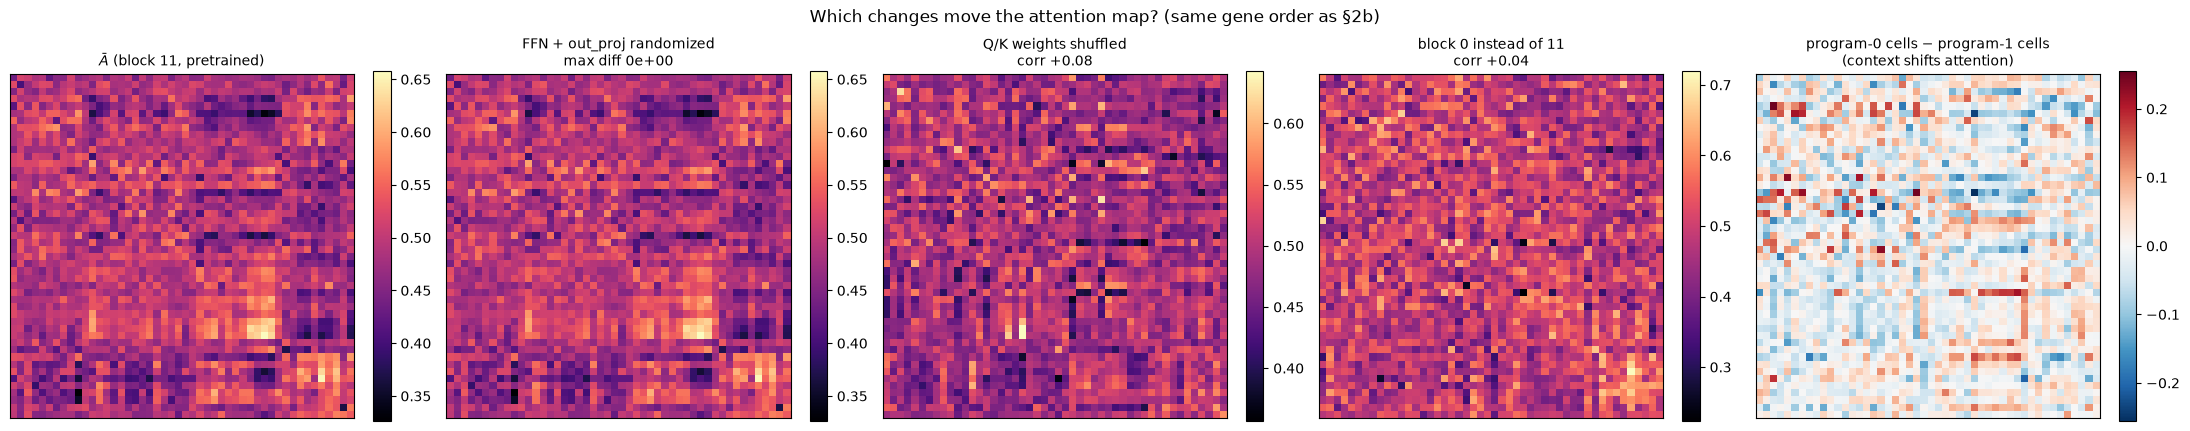

In [8]:
model, vocab, cfg, _ = load_pretrained_scgpt(SCGPT_DIR, device="cpu")
n_bins, cls_value = int(cfg.get("n_bins", 51)), float(cfg.get("pad_value", -2))
gene_ids = torch.tensor([vocab[g] for g in genes])
X_attn = X[: priors.meta["n_cells_aggregated"]]


def attention_map(m, cells=X_attn, layer=-1):
    return paper_attention_map(
        m, gene_ids, cells, cls_id=vocab["<cls>"], cls_value=cls_value,
        n_bins=n_bins, layer_index=layer % m.nlayers,
    )


def corr(a, b):
    return float(np.corrcoef(a.ravel(), b.ravel())[0, 1])


# Test 1 — hooks on an ordinary forward pass
attn_last = model.transformer_encoder.layers[-1].self_attn
captured = {}
hooks = [
    attn_last.Wqkv.register_forward_hook(lambda mod, inp, out: captured.__setitem__("qkv", out)),
    attn_last.register_forward_hook(lambda mod, inp, out: captured.__setitem__("out", out[0])),
]
binned = np.stack([bin_expression(row, n_bins) for row in X_attn])
values = torch.tensor(np.concatenate([np.full((len(X_attn), 1), cls_value), binned], axis=1), dtype=torch.float32)
ids = torch.cat([torch.tensor([vocab["<cls>"]]), gene_ids]).expand(len(X_attn), -1)
with torch.no_grad():
    model(ids, values)
    for h in hooks:
        h.remove()
    q, k, v = rearrange(captured["qkv"], "b s (three h d) -> b s three h d", three=3, h=model.nhead).unbind(dim=2)
    logits = torch.einsum("bshd,bthd->bhst", q, k)
    A_hook = rank_normalize_attention(logits)[:, 1:, 1:].mean(dim=0).numpy()
    probs = torch.softmax(logits / math.sqrt(q.shape[-1]), dim=-1)
    out_manual = attn_last.out_proj(rearrange(torch.einsum("bhst,bthd->bshd", probs, v), "b s h d -> b s (h d)"))

print("Test 1 — forward hooks on block 11")
print(f"  (a) max |A_hook - A_bar|                          = {np.abs(A_hook - A_bar).max():.2e}")
print(f"  (b) max |out_proj(softmax(QK^T/√d)V) - module out| = {(out_manual - captured['out']).abs().max():.2e}")


# Test 2 — knockouts on copies of the model
def knockout(edit):
    m = copy.deepcopy(model)
    with torch.no_grad():
        edit(m.transformer_encoder.layers[-1])
    return attention_map(m)


def randomize_post_logit(layer):
    layer.linear1.weight.normal_()
    layer.self_attn.out_proj.weight.normal_()


def shuffle_qk(layer):
    n_qk = 2 * model.d_model
    W = layer.self_attn.Wqkv.weight
    W[:n_qk] = W[:n_qk][torch.randperm(n_qk)]


torch.manual_seed(0)
A_post = knockout(randomize_post_logit)
A_qk = knockout(shuffle_qk)
A_layer0 = attention_map(model, layer=0)

print("Test 2 — knockouts")
print(f"  randomize block-11 FFN + out_proj : max diff = {np.abs(A_post - A_bar).max():.2e} (expect 0)")
print(f"  shuffle block-11 Q/K weights      : corr with A_bar = {corr(A_qk, A_bar):+.3f}")
print(f"  block 0 instead of block 11       : corr with A_bar = {corr(A_layer0, A_bar):+.3f}")

# Test 3 — context
primary = atlas.program_H.argmax(axis=1)
A_p0 = attention_map(model, cells=X[primary == 0])
A_p1 = attention_map(model, cells=X[primary == 1])
print("Test 3 — context")
print(f"  program-0 cells vs program-1 cells: corr = {corr(A_p0, A_p1):+.3f}, max |diff| = {np.abs(A_p0 - A_p1).max():.3f}")

diff_lim = np.abs(A_p0 - A_p1).max()
fig, axes = plt.subplots(1, 5, figsize=(22, 4.6))
for ax, M, title, kw in [
    (axes[0], A_bar, r"$\bar A$ (block 11, pretrained)", dict(cmap="magma")),
    (axes[1], A_post, f"FFN + out_proj randomized\nmax diff {np.abs(A_post - A_bar).max():.0e}", dict(cmap="magma")),
    (axes[2], A_qk, f"Q/K weights shuffled\ncorr {corr(A_qk, A_bar):+.2f}", dict(cmap="magma")),
    (axes[3], A_layer0, f"block 0 instead of 11\ncorr {corr(A_layer0, A_bar):+.2f}", dict(cmap="magma")),
    (axes[4], A_p0 - A_p1, "program-0 cells − program-1 cells\n(context shifts attention)",
     dict(cmap="RdBu_r", vmin=-diff_lim, vmax=diff_lim)),
]:
    im = ax.imshow(M[np.ix_(order, order)], **kw)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Which changes move the attention map? (same gene order as §2b)", fontsize=12)
fig.tight_layout()
plt.show()
del model

## 3. Four DeltaNMF arms

Same solver (`solve_ntc_regularized`); **only the similarity matrix fed in as `S_E` changes** ([idea.md](../idea.md) §16).

| Arm | Similarity used | What it tests |
|---|---|---|
| **NMF** | none (`alpha_ntc=0`) | Expression-only baseline |
| **Embedding-NMF** | $S_E$ | Vanilla DeltaNMF |
| **Attention-NMF** | $S^{att}$ | Novel prior |
| **Combined-NMF** | $\alpha S_E + (1-\alpha) S^{att}$ | Complementarity |

Combined prior:

$$
S = \alpha S_E + (1-\alpha) S^{att},
\qquad \alpha \in \{0, 0.25, 0.5, 0.75, 1\}.
$$

`recon_mse` = $\mathrm{mean}((X - WH)^2)$. Lower recon means the prior fights the data less — **not** the same as better biology.

Regularized NTC Discovery:   0%|          | 0/300 [00:00<?, ?it/s]

Regularized NTC Discovery:   0%|          | 0/300 [00:00<?, ?it/s]

Regularized NTC Discovery:   0%|          | 0/300 [00:00<?, ?it/s]

Regularized NTC Discovery:   0%|          | 0/300 [00:00<?, ?it/s]

Regularized NTC Discovery:   0%|          | 0/300 [00:00<?, ?it/s]

Regularized NTC Discovery:   0%|          | 0/300 [00:00<?, ?it/s]

Regularized NTC Discovery:   0%|          | 0/300 [00:00<?, ?it/s]

Regularized NTC Discovery:   0%|          | 0/300 [00:00<?, ?it/s]

Regularized NTC Discovery:   0%|          | 0/300 [00:00<?, ?it/s]

DeltaNMF solver × {no FM | S_E | S_att | α-mix}
  model                                         recon_mse
  NMF (DeltaNMF, no FM)                          0.068621
  Embedding-NMF (= DeltaNMF S_E)                 0.076611
  Attention-NMF (novel S_att → DeltaNMF)         0.067331
  Combined-NMF                                   0.073898
  α sweep (Combined; S = α S_E + (1-α) S_att):
    α=0.0    recon_mse=0.067331
    α=0.25   recon_mse=0.071393
    α=0.5    recon_mse=0.073898
    α=0.75   recon_mse=0.075487
    α=1.0    recon_mse=0.076611
  lowest recon among FM arms: Attention-NMF (novel S_att → DeltaNMF)
  read: NMF→Embedding (=DeltaNMF); Embedding→Attention (novel); Attention→Combined (complementary?)


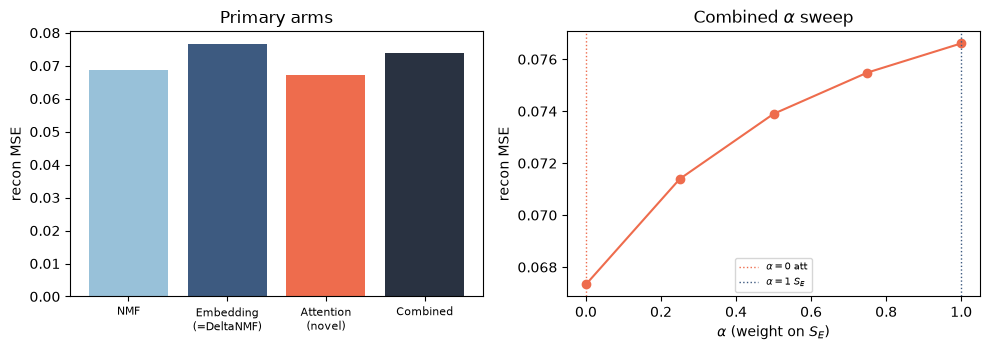

In [9]:
result = run_program_discovery_experiment(
    X, names, priors,
    n_components=K,
    alpha_ntc=0.05,   # DeltaNMF graph strength when a similarity is present
    nmf_iters=300,
    primary_alpha=0.5,
    alphas=DEFAULT_ALPHAS,
    seed=0,
)
print(format_comparison(result))

plot_recon_comparison(result)
plt.show()

### How to read the recon figure

Three pairwise questions ([idea.md](../idea.md) §5):

1. **NMF → Embedding** — does DeltaNMF’s $S_E$ help fit? (often recon rises because the graph constrains $W$)
2. **Embedding → Attention** — does contextual $S^{att}$ behave differently?
3. **Attention → Combined ($\alpha$ sweep)** — is there a sweet spot, or does adding $S_E$ only interpolate toward Embedding?

On synthetic data, treat this as a **feasibility / sensitivity** readout.

### 3b. Proof that the graph is applied to the data

DeltaNMF's solver (`solve_ntc_regularized`) minimizes, by gradient descent (Adam) on $W, H \ge 0$:

$$
\underbrace{\tfrac{1}{GN}\lVert X - WH\rVert_F^2}_{\texttt{recon\_loss}}
\;+\;
\underbrace{\alpha_{ntc}\,\tfrac{1}{GK}\operatorname{Tr}(W^\top L W)}_{\texttt{fm\_loss}},
\qquad
\operatorname{Tr}(W^\top L W)=\tfrac12\sum_{i,j} S_{ij}\,\lVert w_i - w_j\rVert^2 ,
$$

where $w_i$ is gene $i$'s row of $W$ (its loadings across the $K$ programs). The penalty grows when two genes joined by a strong edge get different loadings, so it pulls graph neighbours toward the same programs. $X$ enters only the first term and the graph only the second. The graph therefore acts on the data indirectly, by constraining which factorizations of $X$ are cheap.

Three pieces of evidence:

1. **The penalty is live.** `fm_loss` is non-zero throughout the Attention-NMF fit, so it contributes to every gradient step.
2. **Each arm is smoothest on its own graph.** `graph_smoothness(W, S)` = mean Rayleigh quotient $\tilde w^\top L \tilde w / \tilde w^\top \tilde w$ over mean-centred columns $\tilde w$ (lower = smoother on that graph). Attention-NMF should be smoothest on $S^{att}$ and Embedding-NMF smoothest on $S_E$.
3. **Dose-response with a shuffled-graph control.** Increase $\alpha_{ntc}$. The Attention-NMF $W$ should get smoother on $S^{att}$ but not on *shuffled* copies of $S^{att}$ (same weights and degree distribution, gene labels permuted). A fit that uses a shuffled graph should not get smoother on the real $S^{att}$. This rules out the explanation that "any regularizer just smooths everything".

Regularized NTC Discovery:   0%|          | 0/300 [00:00<?, ?it/s]

Regularized NTC Discovery:   0%|          | 0/300 [00:00<?, ?it/s]

Regularized NTC Discovery:   0%|          | 0/300 [00:00<?, ?it/s]

Regularized NTC Discovery:   0%|          | 0/300 [00:00<?, ?it/s]

Regularized NTC Discovery:   0%|          | 0/300 [00:00<?, ?it/s]

...

Regularized NTC Discovery:   0%|          | 0/300 [00:00<?, ?it/s]

Regularized NTC Discovery:   0%|          | 0/300 [00:00<?, ?it/s]

Regularized NTC Discovery:   0%|          | 0/300 [00:00<?, ?it/s]

Regularized NTC Discovery:   0%|          | 0/300 [00:00<?, ?it/s]

arm × graph smoothness (lower = smoother)
  arm         on S_att    on S_E
  NMF            3.515     5.233
  Embedding      3.574     5.150
  Attention      3.349     5.198
  Combined       3.484     5.189

dose-response
  alpha_ntc  Att-fit on S_att  Att-fit on shuffled  shuffled-fit on S_att    recon
       0.00             3.515                4.287                  3.515   0.0686
       0.05             3.349                4.255                  3.488   0.0673
       0.20             3.108                4.261                  3.522   0.0836
       0.50             2.708                4.292                  3.504   0.1351
       1.00             2.303                4.320                  3.476   0.1988


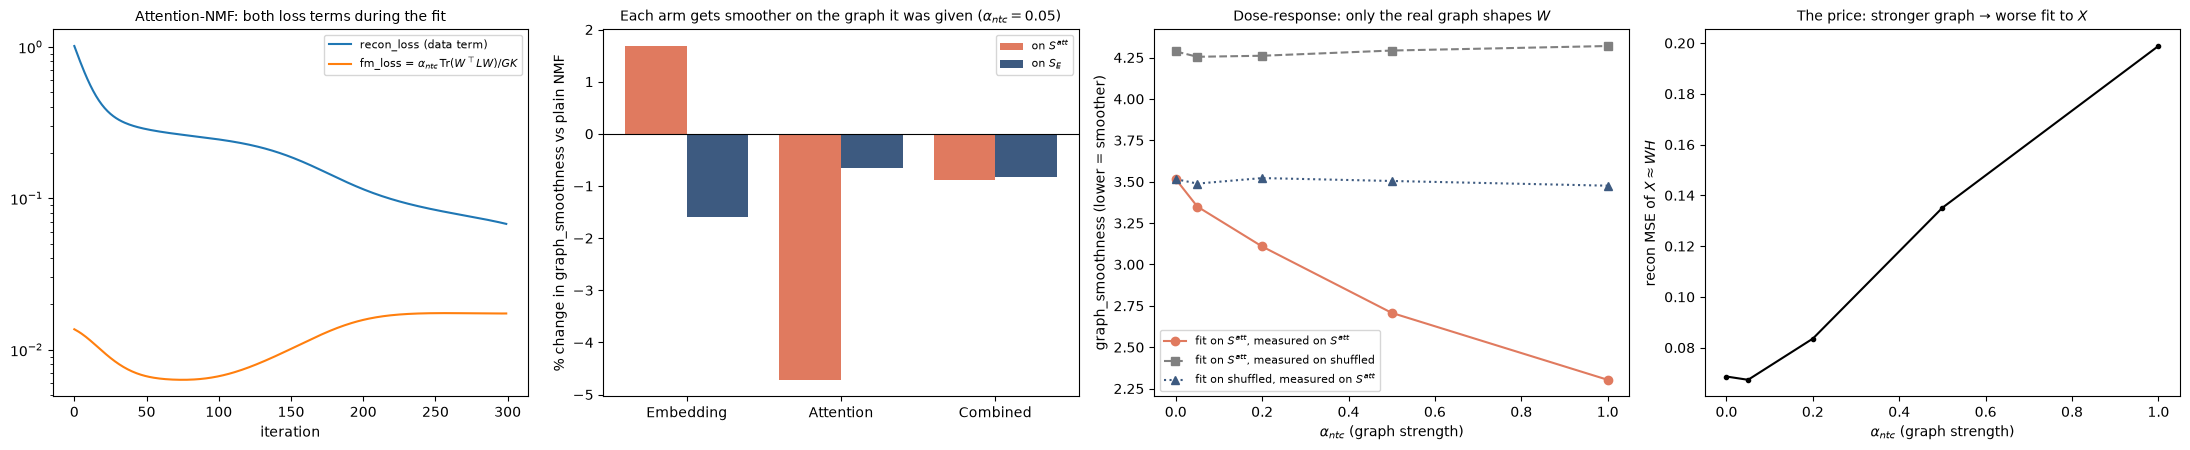

In [10]:
X_gc = X.T.astype(np.float32)   # DeltaNMF orientation: genes × cells
rng = np.random.default_rng(0)
S_shuffled = [S_att[np.ix_(p, p)] for p in (rng.permutation(len(genes)) for _ in range(5))]

hist = result.attention.fit.loss_history

arms = [result.nmf, result.embedding, result.attention, result.combined]
arm_labels = ["NMF", "Embedding", "Attention", "Combined"]
smooth = np.array([[graph_smoothness(a.fit.W, S_att), graph_smoothness(a.fit.W, S_E)] for a in arms])

alphas_ntc = [0.0, 0.05, 0.2, 0.5, 1.0]
dose = []
for a in alphas_ntc:
    fit_att = fit_deltanmf(X_gc, S_att, K=K, alpha_ntc=a, max_iter=300, seed=0)
    fit_shuf = fit_deltanmf(X_gc, S_shuffled[0], K=K, alpha_ntc=a, max_iter=300, seed=0)
    dose.append((
        graph_smoothness(fit_att.W, S_att),
        np.mean([graph_smoothness(fit_att.W, S) for S in S_shuffled[1:]]),
        graph_smoothness(fit_shuf.W, S_att),
        float(np.mean((X_gc - fit_att.W @ fit_att.H) ** 2)),
    ))
dose = np.array(dose)

print("arm × graph smoothness (lower = smoother)")
print(f"  {'arm':<10} {'on S_att':>9} {'on S_E':>9}")
for lbl, (s_att, s_e) in zip(arm_labels, smooth):
    print(f"  {lbl:<10} {s_att:9.3f} {s_e:9.3f}")
print("\ndose-response")
print(f"  {'alpha_ntc':>9} {'Att-fit on S_att':>17} {'Att-fit on shuffled':>20} {'shuffled-fit on S_att':>22} {'recon':>8}")
for a, row in zip(alphas_ntc, dose):
    print(f"  {a:9.2f} {row[0]:17.3f} {row[1]:20.3f} {row[2]:22.3f} {row[3]:8.4f}")

fig, axes = plt.subplots(1, 4, figsize=(22, 4.6))
ax = axes[0]
ax.plot(hist["iteration"], hist["recon_loss"], label="recon_loss (data term)")
ax.plot(hist["iteration"], hist["fm_loss"], label=r"fm_loss = $\alpha_{ntc}\,\mathrm{Tr}(W^\top L W)/GK$")
ax.set_yscale("log")
ax.set_xlabel("iteration")
ax.set_title("Attention-NMF: both loss terms during the fit", fontsize=10)
ax.legend(fontsize=8)

ax = axes[1]
rel = 100 * (smooth / smooth[0] - 1)
x = np.arange(1, len(arms))
ax.bar(x - 0.2, rel[1:, 0], 0.4, label=r"on $S^{att}$", color="#e07a5f")
ax.bar(x + 0.2, rel[1:, 1], 0.4, label=r"on $S_E$", color="#3d5a80")
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x, arm_labels[1:])
ax.set_ylabel("% change in graph_smoothness vs plain NMF")
ax.set_title(r"Each arm gets smoother on the graph it was given ($\alpha_{ntc}=0.05$)", fontsize=10)
ax.legend(fontsize=8)

ax = axes[2]
ax.plot(alphas_ntc, dose[:, 0], "o-", color="#e07a5f", label=r"fit on $S^{att}$, measured on $S^{att}$")
ax.plot(alphas_ntc, dose[:, 1], "s--", color="0.5", label=r"fit on $S^{att}$, measured on shuffled")
ax.plot(alphas_ntc, dose[:, 2], "^:", color="#3d5a80", label=r"fit on shuffled, measured on $S^{att}$")
ax.set_xlabel(r"$\alpha_{ntc}$ (graph strength)")
ax.set_ylabel("graph_smoothness (lower = smoother)")
ax.set_title("Dose-response: only the real graph shapes $W$", fontsize=10)
ax.legend(fontsize=8)

ax = axes[3]
ax.plot(alphas_ntc, dose[:, 3], "k.-")
ax.set_xlabel(r"$\alpha_{ntc}$ (graph strength)")
ax.set_ylabel(r"recon MSE of $X \approx WH$")
ax.set_title("The price: stronger graph → worse fit to $X$", fontsize=10)
fig.tight_layout()
plt.show()

### Reading §3b

- **Loss curves.** `fm_loss` is never zero, so the attention graph contributes to every gradient step. It rises late in the fit as $W$ sharpens into distinct programs, because distinct programs are less smooth.
- **Arm bars.** Relative to plain NMF, Attention-NMF becomes smoother on $S^{att}$ (about −5%) and barely changes on $S_E$. Embedding-NMF does the opposite: it becomes smoother on $S_E$ and actually *rougher* on $S^{att}$. Each prior pushes $W$ toward its own graph and not the other's.
- **Dose-response.** Only the orange line falls. Shuffled graphs have identical edge weights and degrees, so a generic "regularizers smooth everything" effect would move the grey and blue lines too. They stay flat, so what shapes $W$ is the specific gene pairing that scGPT's attention produced.
- **Caveat.** At the notebook's `alpha_ntc=0.05` the effect is real but modest (about 5%). Stronger graphs reshape $W$ more but cost reconstruction, which is the usual bias/fit trade-off. Choose `alpha_ntc` on held-out data, not by eye.

## 4. Do the recovered *programs* change?

Recon alone is insufficient. NMF factors are defined up to **column permutation**, so we greedily align non-Embedding arms to Embedding-NMF by absolute column correlation before plotting.

We look at four views:

1. **$W$ heatmaps** — gene loadings for all four arms
2. **Arm similarity matrix** — mean $|$corr$|$ of aligned $W$ columns
3. **Top genes** — Embedding vs Attention, per program
4. **$H$ heatmaps** — cell usage of programs

W shapes: {'NMF (DeltaNMF, no FM)': (48, 4), 'Embedding-NMF (= DeltaNMF S_E)': (48, 4), 'Attention-NMF (novel S_att → DeltaNMF)': (48, 4), 'Combined-NMF': (48, 4)}
H shapes: {'NMF (DeltaNMF, no FM)': (4, 80), 'Embedding-NMF (= DeltaNMF S_E)': (4, 80), 'Attention-NMF (novel S_att → DeltaNMF)': (4, 80), 'Combined-NMF': (4, 80)}


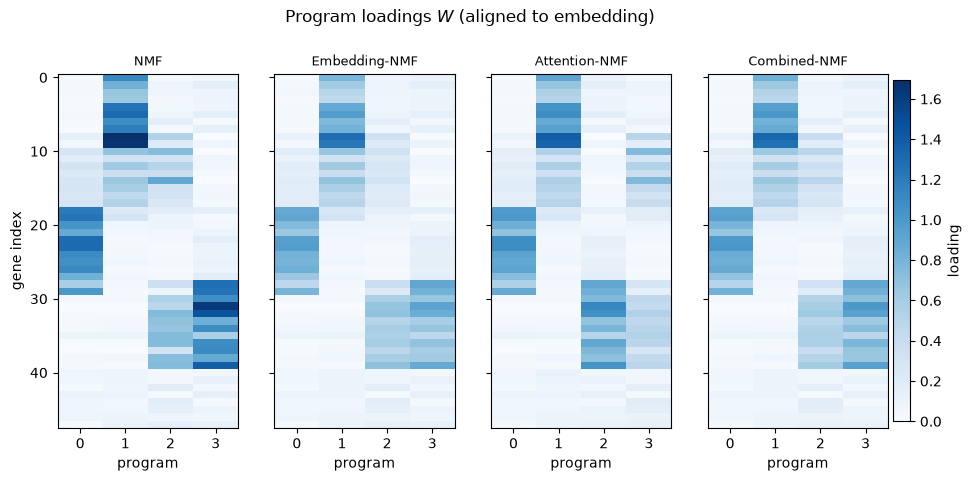

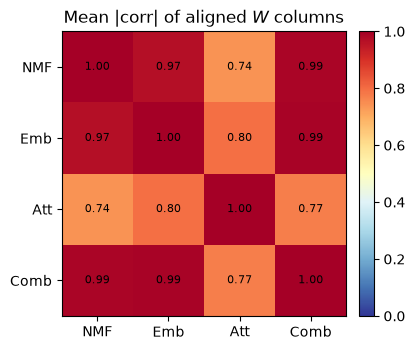

In [11]:
print("W shapes:", {arm.name: arm.fit.W.shape for arm in [
    result.nmf, result.embedding, result.attention, result.combined
]})
print("H shapes:", {arm.name: arm.fit.H.shape for arm in [
    result.nmf, result.embedding, result.attention, result.combined
]})

plot_program_loadings(result, priors.gene_names, align_to="embedding")
plt.show()

plot_arm_W_similarity(result)
plt.show()

### Reading $W$ + similarity

- If Attention and Embedding heatmaps look nearly identical and the similarity matrix is ~0.97–1.0, the novel prior **did not materially change programs** on this matrix (even if recon differs slightly).
- If blocks shift or the Att↔Emb entry drops, the prior is doing real work on $W$.

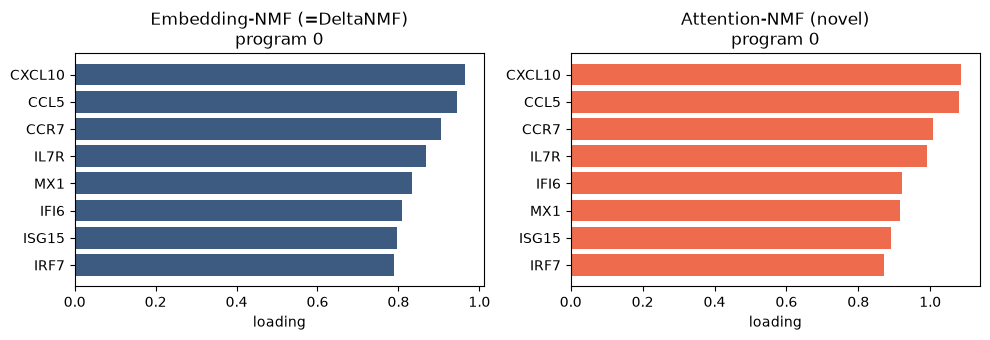

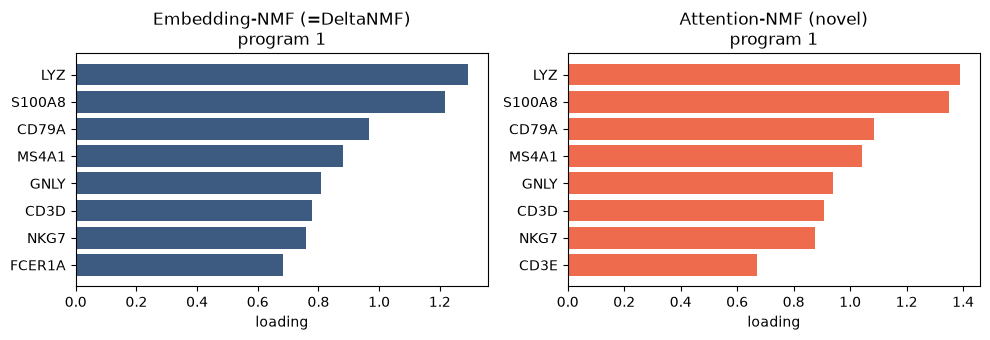

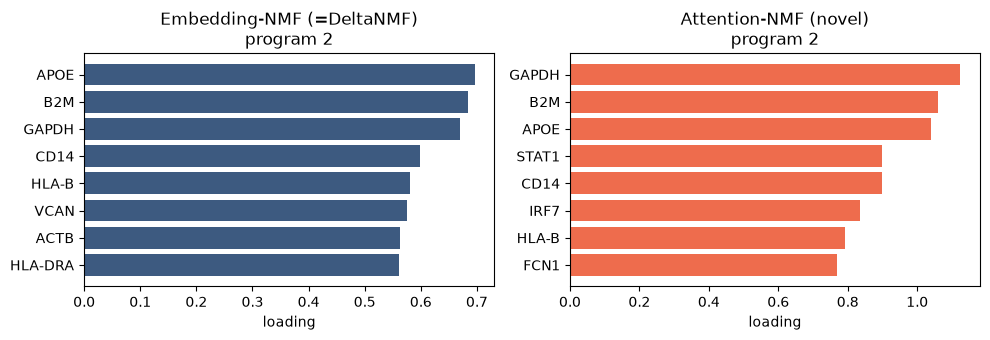

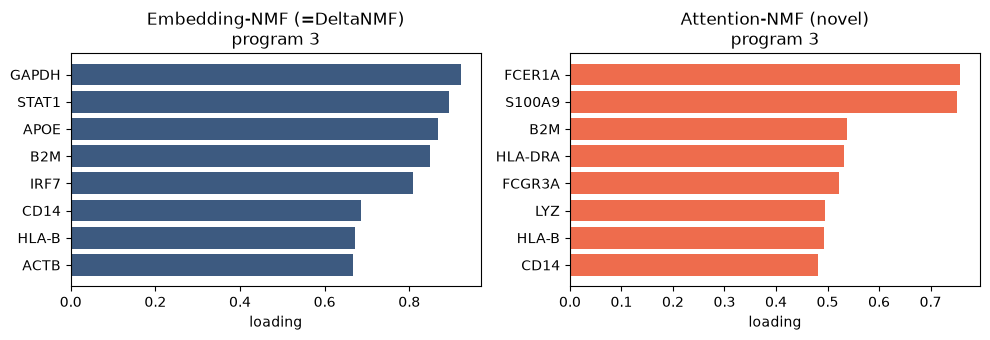

In [12]:
# Top genes for every program: Embedding (blue) vs Attention (orange).
# Same rank order ⇒ programs agree; swaps in the tail ⇒ mild disagreement.
for prog in range(K):
    plot_top_genes_comparison(result, priors.gene_names, program=prog, top_n=8)
    plt.show()

### Cell-level program usage ($H$)

$H$ says **which cells use which programs**. Attention’s $H$ is row-aligned to Embedding via the same permutation used for $W$, so differences are content, not reordering.

On the synthetic atlas you should still see the planted block / step structure; compare whether Attention smooths or reshapes those blocks relative to Embedding.

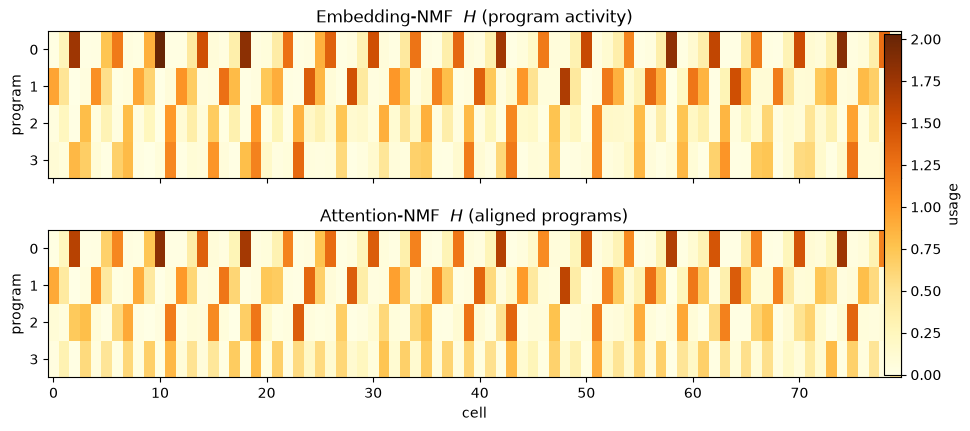

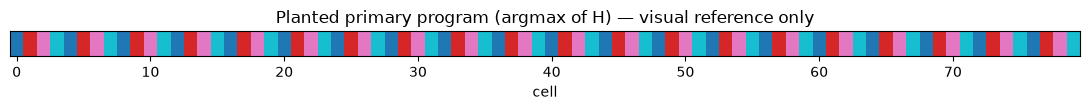

In [13]:
plot_cell_program_usage(result, max_cells=N_CELLS)
plt.show()

# Optional: overlay planted primary program per cell as a reference strip.
primary = atlas.program_H.argmax(axis=1)
fig, ax = plt.subplots(figsize=(11, 1.2))
ax.imshow(primary[None, :], aspect="auto", cmap="tab10", vmin=0, vmax=max(K - 1, 1))
ax.set_yticks([])
ax.set_xlabel("cell")
ax.set_title("Planted primary program (argmax of H) — visual reference only")
fig.tight_layout()
plt.show()

## 5. How to read everything together

| Figure | Question |
|---|---|
| Atlas / $X$ histograms | Is the input well-formed? |
| Prior diagnostics + heatmaps + scatter | Does $S^{att}$ differ from DeltaNMF $S_E$? ([idea.md](../idea.md) §17-B) |
| Recon bars / $\alpha$ sweep | Does the attention prior change fit quality? (§17-C) |
| $W$ heatmaps + similarity matrix | Do programs *themselves* change, not just recon? |
| Top-gene bars | Which genes move between Embedding vs Attention? |
| $H$ heatmaps + planted strip | Does cell usage of programs shift? |

### What this notebook is *not*

- Not a claim that attention improves biological coherence on real tissue.
- Not Stage-2 condition-specific $\Delta S$ ([idea.md](../idea.md) §14).

## Next

1. Real AnnData + full DeltaNMF `run_onestage_deltanmf`.
2. Layer / $k$ ablations for attention only.
3. Condition-specific $S^{att}$.